In [1]:
# Import libraries
import sys
import os
import json
import pandas as pd
from pathlib import Path
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Add the src directory to Python path
project_root = Path.cwd().parent.parent  # Go up to bonn_thesis/src/
sys.path.insert(0, str(project_root))

# Set pandas options
pd.set_option('display.max_columns', None)

from bonn_thesis.config import LINKEDIN_MATCHED_TO_SOEP_BLD


## Load data

Data is loaded from the following files:
* wage_linkedin_exp_xx_results.jsonl: this file contains LLM labor income estimates using the OpenAI API for LinkedIn profiles. 
* linkedin_agg_part_xx.parquet: these are the individual LinkedIn profile observations matched to SOEP demographic cells.
* soep_selected.parquet: these are the SOEP individual-level observations that serve as reference wages.

&lt;br&gt;Income estimates are extracted from the responses and there's a condition that income should be &gt;10.000 euros. This is because the responses are limited to 20 tokens and some responses have extra characters (despite explicitly asking for numbers only). So it can happen that numbers appear not completely.
&lt;br&gt;Income is estimated yearly and converted to monthly income by dividing by 12 months to match the monthly gross labor income in SOEP
&lt;br&gt;&lt;br&gt;After loading, the data is **grouped** by syear, isco_3_name, education_grouped, sex_en, and state_en to compute average wages within each demographic group.

In [2]:
# Define the experiment number you want to load
experiment_num = "14"

# Get all matching files
openai_responses_dir = LINKEDIN_MATCHED_TO_SOEP_BLD / "openai_responses"
matching_files = sorted(openai_responses_dir.glob(f"wage_linkedin_exp_{experiment_num}*.jsonl"))

print(f"Found {len(matching_files)} files for experiment {experiment_num}:")
for file in matching_files:
    print(f"  - {file.name}")

# Load all matching files
openai_data = []
for file_path in matching_files:
    with open(file_path, 'r') as f:
        for line in f:
            openai_data.append(json.loads(line))

print(f"\nTotal responses loaded: {len(openai_data)}")

Found 2 files for experiment 14:
  - wage_linkedin_exp_14a_results.jsonl
  - wage_linkedin_exp_14b_results.jsonl

Total responses loaded: 29178


In [3]:
# Load LinkedIn aggregated data
linkedin_agg_path = LINKEDIN_MATCHED_TO_SOEP_BLD / "aggregated" / "linkedin_agg_part_14.parquet"
linkedin_df = pd.read_parquet(linkedin_agg_path)
print(f"LinkedIn data shape: {linkedin_df.shape}")
print(f"Columns: {linkedin_df.columns.tolist()}")

LinkedIn data shape: (29178, 45)
Columns: ['exp_id', 'prof_id', 'comp_id', 'industry_id', 'job_title_id', 'job_title', 'exp_description', 'exp_company', 'industry', 'matched_city', 'matched_state', 'bland_code', 'match_method', 'experience_at_start_recalc', 'experience_at_start_ft', 'exp_start_date', 'exp_end_date', 'duration', 'date_reconstruction_method', 'is_overlapping_reference', 'gender', 'hierarchy', 'hierarchy_name', 'comp_type', 'min_size', 'max_size', 'total_size', 'isco_3_digit', 'syear', 'pgexpft_mean', 'ed_id', 'ed_start_date', 'ed_end_date', 'education_grouped', 'isco_2_digit', 'isco_1_digit', 'isco_1_name', 'isco_2_name', 'isco_3_name', 'sex_en', 'state_en', 'state_de', 'custom_id', 'soep_n_obs', 'n_obs']


In [4]:
# Load SOEP reference data
soep_ref_path = LINKEDIN_MATCHED_TO_SOEP_BLD / "soep_selected.parquet"
soep_ref_df = pd.read_parquet(soep_ref_path)
print(f"SOEP reference data shape: {soep_ref_df.shape}")
print(f"Columns: {soep_ref_df.columns.tolist()}")

SOEP reference data shape: (17341, 33)
Columns: ['hid', 'pid', 'syear', 'pgkldb2010', 'pgisco08', 'pgisced11', 'pgexpft', 'pgemplst', 'pglabgro', 'pglabnet', 'sex', 'bula_h', 'isco_code', 'isco_3_digit', 'isco_2_digit', 'isco_1_digit', 'isco_1_name', 'isco_2_name', 'isco_3_name', 'isco_4_name', 'kldb_code', 'kldb_4_digit', 'kldb_3_digit', 'kldb_2_digit', 'kldb_1_digit', 'kldb_skill', 'isced_code', 'education', 'education_grouped', 'sex_en', 'bland_code', 'state_en', 'state_de']


In [5]:
# Extract wage estimates from OpenAI responses
def extract_wage(response_obj):
    """Extract numeric wage from OpenAI response content."""
    try:
        # Get the content from the response
        content = response_obj['response']['body']['choices'][0]['message']['content']
        
        # Remove common text patterns
        content = content.lower()
        content = content.replace('approximately', '')
        content = content.replace('estimate:', '')
        content = content.replace('euros', '')
        content = content.replace('euro', '')
        content = content.replace('€', '')
        content = content.replace(',', '')
        content = content.replace('.', '')
        content = content.strip()
        
        # Extract first number found
        numbers = re.findall(r'\d+', content)
        if numbers:
            wage = float(numbers[0])
            if wage > 10000:
                return wage
        return None
    except:
        return None

# Create DataFrame with custom_id and extracted wages
openai_df = pd.DataFrame([
    {
        'custom_id': item['custom_id'],
        'llm_income': extract_wage(item)
    }
    for item in openai_data
])

print(f"Successfully extracted {openai_df['llm_income'].notna().sum()} wages")
print(f"Missing wages: {openai_df['llm_income'].isna().sum()}")

Successfully extracted 28929 wages
Missing wages: 249


In [6]:
# Merge LinkedIn data with LLM estimates
merged_df = linkedin_df.merge(openai_df, on='custom_id', how='inner')

# Convert annual to monthly wage
merged_df["llm_income"] = merged_df["llm_income"]/12

print(f"Merged LinkedIn-LLM dataset has {len(merged_df)} rows")
print(f"\nMissing LLM income: {merged_df['llm_income'].isna().sum()}")

Merged LinkedIn-LLM dataset has 29178 rows

Missing LLM income: 249


In [7]:
# Filter and prepare LinkedIn data (individual level)
# Filter out zero or negative wages and missing values
linkedin_individual = merged_df[
    (merged_df['llm_income'] > 10000/12) & 
    (merged_df['llm_income'].notna())
].copy()

# Create log wage variables
linkedin_individual['log_llm_income'] = np.log(linkedin_individual['llm_income'])

# Calculate experience squared if experience exists
if 'pgexpft' in linkedin_individual.columns:
    linkedin_individual['pgexpft_sq'] = (linkedin_individual['pgexpft'] ** 2) / 100
elif 'pgexpft_mean' in linkedin_individual.columns:
    linkedin_individual['pgexpft_sq'] = (linkedin_individual['pgexpft_mean'] ** 2) / 100

print(f"LinkedIn individual-level data: {len(linkedin_individual)} observations")
print(f"Log LLM income - Mean: {linkedin_individual['log_llm_income'].mean():.4f}, Std: {linkedin_individual['log_llm_income'].std():.4f}")

LinkedIn individual-level data: 28929 observations
Log LLM income - Mean: 8.1905, Std: 0.5689


In [8]:
# Filter and prepare SOEP data (individual level)
# Filter out zero or negative wages
soep_individual = soep_ref_df[
    (soep_ref_df['pglabgro'] > 10000/12) & 
    (soep_ref_df['pglabgro'].notna())
].copy()

# Create log wage variables
soep_individual['log_pglabgro'] = np.log(soep_individual['pglabgro'])

# Calculate experience squared
if 'pgexpft' in soep_individual.columns:
    soep_individual['pgexpft_sq'] = (soep_individual['pgexpft'] ** 2) / 100

print(f"SOEP individual-level data: {len(soep_individual)} observations")
print(f"Log pglabgro - Mean: {soep_individual['log_pglabgro'].mean():.4f}, Std: {soep_individual['log_pglabgro'].std():.4f}")

SOEP individual-level data: 17132 observations
Log pglabgro - Mean: 8.1787, Std: 0.5291


In [9]:
# Define demographic grouping variables
groupby_vars = ['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en']

# Group LinkedIn data by demographic characteristics
# Aggregate LinkedIn data
agg_dict_linkedin = {
    'llm_income': 'mean',
    'log_llm_income': 'mean',
    'exp_id': 'count'  # Count LinkedIn profiles per group
}

# Add experience variables if available
if 'pgexpft' in linkedin_individual.columns:
    agg_dict_linkedin['pgexpft'] = 'mean'
if 'pgexpft_mean' in linkedin_individual.columns:
    agg_dict_linkedin['pgexpft_mean'] = 'mean'
if 'pgexpft_sq' in linkedin_individual.columns:
    agg_dict_linkedin['pgexpft_sq'] = 'mean'

linkedin_grouped = linkedin_individual.groupby(groupby_vars).agg(agg_dict_linkedin).reset_index()

# Rename columns
rename_dict_linkedin = {
    'llm_income': 'llm_income_mean',
    'log_llm_income': 'log_llm_income_mean',
    'exp_id': 'n_obs'
}

if 'pgexpft' in linkedin_grouped.columns:
    rename_dict_linkedin['pgexpft'] = 'pgexpft_mean'
if 'pgexpft_mean' in linkedin_grouped.columns:
    rename_dict_linkedin['pgexpft_mean'] = 'pgexpft_mean'
if 'pgexpft_sq' in linkedin_grouped.columns:
    rename_dict_linkedin['pgexpft_sq'] = 'pgexpft_sq_mean'

linkedin_grouped = linkedin_grouped.rename(columns=rename_dict_linkedin)

print(f"LinkedIn grouped data: {len(linkedin_grouped)} demographic groups")
print(f"Total LinkedIn profiles: {linkedin_grouped['n_obs'].sum()}")
print(f"\nGroup size statistics:")
print(f"  Mean: {linkedin_grouped['n_obs'].mean():.2f}")
print(f"  Median: {linkedin_grouped['n_obs'].median():.0f}")
print(f"  Min: {linkedin_grouped['n_obs'].min()}")
print(f"  Max: {linkedin_grouped['n_obs'].max()}")

LinkedIn grouped data: 1721 demographic groups
Total LinkedIn profiles: 28929

Group size statistics:
  Mean: 16.81
  Median: 14
  Min: 3
  Max: 122


In [10]:
# Group SOEP data by demographic characteristics
agg_dict_soep = {
    'pglabgro': 'mean',
    'log_pglabgro': 'mean',
    'pid': 'count'
}

# Add experience variables if available
if 'pgexpft' in soep_individual.columns:
    agg_dict_soep['pgexpft'] = 'mean'
if 'pgexpft_sq' in soep_individual.columns:
    agg_dict_soep['pgexpft_sq'] = 'mean'

soep_grouped = soep_individual.groupby(groupby_vars).agg(agg_dict_soep).reset_index()

# Rename columns
rename_dict_soep = {
    'pglabgro': 'pglabgro_mean',
    'log_pglabgro': 'log_pglabgro_mean',
    'pid': 'soep_n_obs_actual'
}

if 'pgexpft' in soep_grouped.columns:
    rename_dict_soep['pgexpft'] = 'pgexpft_soep_mean'
if 'pgexpft_sq' in soep_grouped.columns:
    rename_dict_soep['pgexpft_sq'] = 'pgexpft_sq_soep_mean'

soep_grouped = soep_grouped.rename(columns=rename_dict_soep)

print(f"SOEP grouped data: {len(soep_grouped)} demographic groups")
print(f"Total SOEP observations: {soep_grouped['soep_n_obs_actual'].sum()}")
print(f"\nGroup size statistics:")
print(f"  Mean: {soep_grouped['soep_n_obs_actual'].mean():.2f}")
print(f"  Median: {soep_grouped['soep_n_obs_actual'].median():.0f}")
print(f"  Min: {soep_grouped['soep_n_obs_actual'].min()}")
print(f"  Max: {soep_grouped['soep_n_obs_actual'].max()}")

SOEP grouped data: 1721 demographic groups
Total SOEP observations: 17132

Group size statistics:
  Mean: 9.95
  Median: 7
  Min: 3
  Max: 53


In [11]:
# Merge the grouped datasets on demographic characteristics
final_df = linkedin_grouped.merge(
    soep_grouped,
    on=['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en'],
    how='inner'
)

print(f"Final merged dataset has {len(final_df)} demographic groups")
print(f"Total LinkedIn observations: {final_df['n_obs'].sum()}")
print(f"Total SOEP observations: {final_df['soep_n_obs_actual'].sum()}")
print(f"\nColumns: {final_df.columns.tolist()}")

Final merged dataset has 1721 demographic groups
Total LinkedIn observations: 28929
Total SOEP observations: 17132

Columns: ['syear', 'isco_3_name', 'education_grouped', 'sex_en', 'state_en', 'llm_income_mean', 'log_llm_income_mean', 'n_obs', 'pgexpft_mean', 'pgexpft_sq_mean', 'pglabgro_mean', 'log_pglabgro_mean', 'soep_n_obs_actual', 'pgexpft_soep_mean', 'pgexpft_sq_soep_mean']


In [12]:
# Display the merged grouped data
final_df

,syear,isco_3_name,education_grouped,sex_en,state_en,llm_income_mean,log_llm_income_mean,n_obs,pgexpft_mean,pgexpft_sq_mean,pglabgro_mean,log_pglabgro_mean,soep_n_obs_actual,pgexpft_soep_mean,pgexpft_sq_soep_mean
0,2013.0,Administration Professionals,Bachelor degree,male,Bavaria,5264.705882,8.497562,17,13.457988,2.671474,4532.000000,8.289442,5,14.383600,3.623667
1,2013.0,Administration Professionals,Master or Doctoral degree,male,North Rhine-Westphalia,6011.904762,8.671379,21,18.507223,4.726055,7342.857143,8.761219,7,18.654714,4.802451
2,2013.0,Administrative and Specialized Secretaries,Post-secondary non-tertiary or Short-cycle ter...,female,North Rhine-Westphalia,2825.757576,7.927402,11,16.142376,3.193664,2480.000000,7.812660,5,18.216800,3.882201
3,2013.0,Administrative and Specialized Secretaries,Secondary education,female,Baden-Württemberg,2486.111111,7.787380,12,6.284102,0.719721,3188.571429,8.016713,7,11.083429,1.733652
4,2013.0,Administrative and Specialized Secretaries,Secondary education,female,Bavaria,2717.948718,7.889518,13,9.601065,1.269814,2858.333333,7.870912,6,12.430500,2.113759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716,2019.0,Transport and Storage Labourers,Secondary education,male,North Rhine-Westphalia,1819.444444,7.477090,24,4.352869,0.423715,2130.357143,7.641189,14,12.023786,2.225859
1717,2019.0,University and Higher Education Teachers,Master or Doctoral degree,male,Bavaria,4396.825397,8.319980,21,15.374276,3.158940,5714.500000,8.613093,8,16.687500,3.677344
1718,2019.0,University and Higher Education Teachers,Master or Doctoral degree,male,Berlin,3654.761905,8.179843,7,10.925065,1.779173,4698.333333,8.446264,6,5.861167,0.880905
1719,2019.0,University and Higher Education Teachers,Master or Doctoral degree,male,Hesse,4658.730159,8.418519,21,15.862184,3.382294,6354.000000,8.732652,7,15.714286,3.294286


## Group data by demographics

Group LinkedIn profiles by demographic characteristics and compute mean wages within each group.

In [13]:
# The data is now already grouped, so we just assign it to grouped_df
grouped_df = final_df.copy()

print(f"Grouped dataset: {len(grouped_df)} demographic groups")
print(f"Total LinkedIn profiles: {grouped_df['n_obs'].sum()}")
print(f"Total SOEP observations: {grouped_df['soep_n_obs_actual'].sum()}")
print(f"\nLinkedIn group size statistics:")
print(f"  Mean: {grouped_df['n_obs'].mean():.2f}")
print(f"  Median: {grouped_df['n_obs'].median():.0f}")
print(f"  Min: {grouped_df['n_obs'].min()}")
print(f"  Max: {grouped_df['n_obs'].max()}")
print(f"\nSOEP group size statistics:")
print(f"  Mean: {grouped_df['soep_n_obs_actual'].mean():.2f}")
print(f"  Median: {grouped_df['soep_n_obs_actual'].median():.0f}")
print(f"  Min: {grouped_df['soep_n_obs_actual'].min()}")
print(f"  Max: {grouped_df['soep_n_obs_actual'].max()}")

Grouped dataset: 1721 demographic groups
Total LinkedIn profiles: 28929
Total SOEP observations: 17132

LinkedIn group size statistics:
  Mean: 16.81
  Median: 14
  Min: 3
  Max: 122

SOEP group size statistics:
  Mean: 9.95
  Median: 7
  Min: 3
  Max: 53


## Filter by minimum group size

Filter out groups with too few observations to ensure reliable estimates.

In [14]:
# Set minimum number of observations per group
min_obs_per_group = 1

# Filter groups by minimum size
print(f"Before filtering: {len(grouped_df)} groups, {grouped_df['n_obs'].sum()} total observations")
print(f"\nGroup size distribution before filtering:")
print(f"  Mean: {grouped_df['n_obs'].mean():.2f}")
print(f"  Median: {grouped_df['n_obs'].median():.0f}")
print(f"  Min: {grouped_df['n_obs'].min()}")
print(f"  Max: {grouped_df['n_obs'].max()}")
print(f"  Groups with n_obs < {min_obs_per_group}: {(grouped_df['n_obs'] < min_obs_per_group).sum()}")

# Apply filter
grouped_df = grouped_df[grouped_df['n_obs'] >= min_obs_per_group].copy()

print(f"\n{'-'*60}")
print(f"After filtering (keeping groups with n_obs >= {min_obs_per_group}):")
print(f"  {len(grouped_df)} groups, {grouped_df['n_obs'].sum()} total observations")
print(f"\nGroup size distribution after filtering:")
print(f"  Mean: {grouped_df['n_obs'].mean():.2f}")
print(f"  Median: {grouped_df['n_obs'].median():.0f}")
print(f"  Min: {grouped_df['n_obs'].min()}")
print(f"  Max: {grouped_df['n_obs'].max()}")

Before filtering: 1721 groups, 28929 total observations

Group size distribution before filtering:
  Mean: 16.81
  Median: 14
  Min: 3
  Max: 122
  Groups with n_obs < 1: 0

------------------------------------------------------------
After filtering (keeping groups with n_obs >= 1):
  1721 groups, 28929 total observations

Group size distribution after filtering:
  Mean: 16.81
  Median: 14
  Min: 3
  Max: 122


## Descriptive statistics & wage distributions

In [15]:
# Remove rows with missing wages from grouped data
valid_df = grouped_df.dropna(subset=['llm_income_mean', 'pglabgro_mean']).copy()

# Compute measurement error based on group means
valid_df["measurement_error"] = valid_df['llm_income_mean'] - valid_df['pglabgro_mean']
valid_df["measurement_error_log"] = valid_df['log_llm_income_mean'] - valid_df['log_pglabgro_mean']

# Keep observations where measurement_error_log < 1.50 in absolute value
valid_df = valid_df[valid_df["measurement_error_log"].abs() < 1.5].copy()

print(f"After filtering, valid_df has {len(valid_df)} groups")
print(f"Total weighted observations: {valid_df['soep_n_obs_actual'].sum()}")

print(f"\nWage statistics (unweighted):")
print(f"    SOEP: mean={valid_df['pglabgro_mean'].mean():.4f}, std={valid_df['pglabgro_mean'].std():.4f}")
print(f"    LinkedIn-LLM: mean={valid_df['llm_income_mean'].mean():.4f}, std={valid_df['llm_income_mean'].std():.4f}")

print(f"\nLog wage statistics (unweighted):")
print(f"    Log SOEP: mean={valid_df['log_pglabgro_mean'].mean():.4f}, std={valid_df['log_pglabgro_mean'].std():.4f}")
print(f"    Log LinkedIn-LLM: mean={valid_df['log_llm_income_mean'].mean():.4f}, std={valid_df['log_llm_income_mean'].std():.4f}")

After filtering, valid_df has 1721 groups
Total weighted observations: 17132

Wage statistics (unweighted):
    SOEP: mean=4429.0506, std=2299.4111
    LinkedIn-LLM: mean=4111.0998, std=2310.0657

Log wage statistics (unweighted):
    Log SOEP: mean=8.2278, std=0.4026
    Log LinkedIn-LLM: mean=8.1514, std=0.4906


In [16]:
# Print summary statistics (weighted)
print("\nWage Statistics (weighted)")
print(f"    SOEP: mean={np.average(valid_df['pglabgro_mean'], weights=valid_df['soep_n_obs_actual']):.2f}, std={np.sqrt(np.average((valid_df['pglabgro_mean'] - np.average(valid_df['pglabgro_mean'], weights=valid_df['soep_n_obs_actual']))**2, weights=valid_df['soep_n_obs_actual'])):.2f}")
print(f"    LinkedIn-LLM: mean={np.average(valid_df['llm_income_mean'], weights=valid_df['soep_n_obs_actual']):.2f}, std={np.sqrt(np.average((valid_df['llm_income_mean'] - np.average(valid_df['llm_income_mean'], weights=valid_df['soep_n_obs_actual']))**2, weights=valid_df['soep_n_obs_actual'])):.2f}")

print(f"\nLog wage statistics (weighted):")
print(f"    Log SOEP: mean={np.average(valid_df['log_pglabgro_mean'], weights=valid_df['soep_n_obs_actual']):.2f}, std={np.sqrt(np.average((valid_df['log_pglabgro_mean'] - np.average(valid_df['log_pglabgro_mean'], weights=valid_df['soep_n_obs_actual']))**2, weights=valid_df['soep_n_obs_actual'])):.2f}")
print(f"    Log LinkedIn-LLM: mean={np.average(valid_df['log_llm_income_mean'], weights=valid_df['soep_n_obs_actual']):.2f}, std={np.sqrt(np.average((valid_df['log_llm_income_mean'] - np.average(valid_df['log_llm_income_mean'], weights=valid_df['soep_n_obs_actual']))**2, weights=valid_df['soep_n_obs_actual'])):.2f}")


Wage Statistics (weighted)
    SOEP: mean=4176.25, std=2097.58
    LinkedIn-LLM: mean=3820.78, std=2134.17

Log wage statistics (weighted):
    Log SOEP: mean=8.18, std=0.39
    Log LinkedIn-LLM: mean=8.09, std=0.47


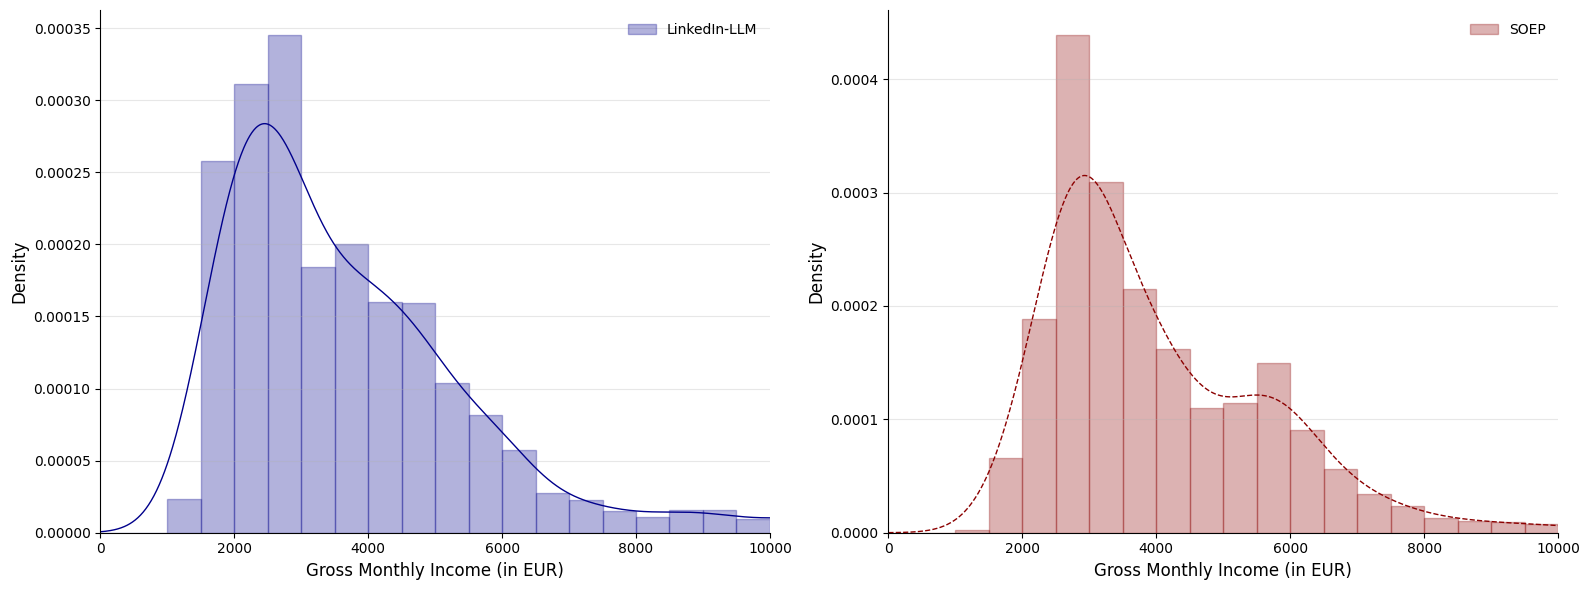

In [17]:
# Plot weighted wage distributions with 500 euro bins and density functions
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define bins of 500 euros
min_wage = 0
max_wage = 10000
bins = np.arange(0, max_wage + 500, 500)

# Plot LinkedIn-LLM wage distribution (weighted)
counts, _, patches = axes[0].hist(valid_df['llm_income_mean'], bins=bins, weights=valid_df['soep_n_obs_actual'], 
                                   alpha=0.3, color='darkblue', edgecolor='darkblue', label='LinkedIn-LLM', density=True)
# Add KDE
kde_linkedin = gaussian_kde(valid_df['llm_income_mean'], weights=valid_df['soep_n_obs_actual'])
x_range_linkedin = np.linspace(0, 10000, 1000)
axes[0].plot(x_range_linkedin, kde_linkedin(x_range_linkedin), color='darkblue', linewidth=1, linestyle='-')
axes[0].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_xlim(0, 10000)
axes[0].legend(frameon=False, fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Plot SOEP wage distribution (weighted)
counts, _, patches = axes[1].hist(valid_df['pglabgro_mean'], bins=bins, weights=valid_df['soep_n_obs_actual'], 
                                   alpha=0.3, color='darkred', edgecolor='darkred', label='SOEP', density=True)
# Add KDE
kde_soep = gaussian_kde(valid_df['pglabgro_mean'], weights=valid_df['soep_n_obs_actual'])
x_range = np.linspace(0, 10000, 1000)
axes[1].plot(x_range, kde_soep(x_range), color='darkred', linewidth=1, linestyle='--')
axes[1].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_xlim(0, 10000)
axes[1].legend(frameon=False, fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

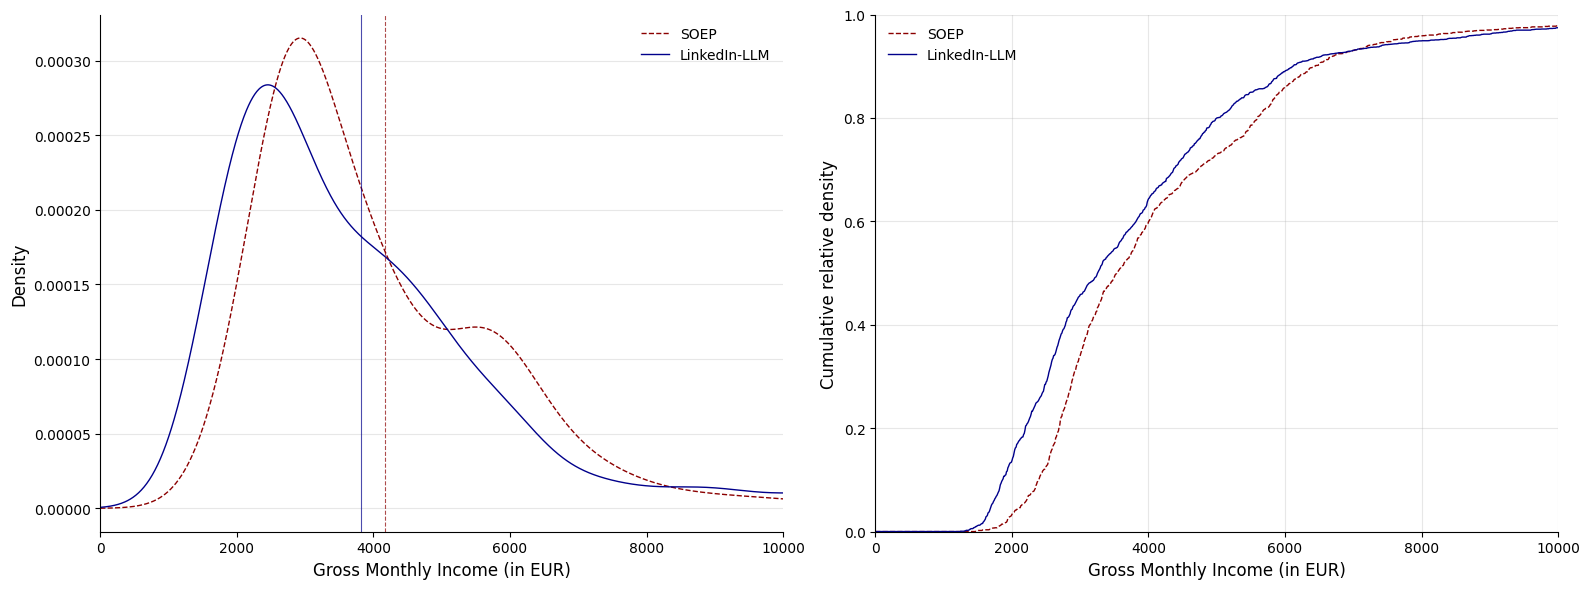

In [18]:
# Create density and cumulative density plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate weighted averages
soep_mean = np.average(valid_df['pglabgro_mean'], weights=valid_df['soep_n_obs_actual'])
linkedin_mean = np.average(valid_df['llm_income_mean'], weights=valid_df['soep_n_obs_actual'])

# Left panel: Density functions only
x_range_plot = np.linspace(0, 10000, 1000)
axes[0].plot(x_range_plot, kde_soep(x_range_plot), color='darkred', linewidth=1, linestyle='--', label='SOEP')
axes[0].plot(x_range_plot, kde_linkedin(x_range_plot), color='darkblue', linewidth=1, linestyle='-', label='LinkedIn-LLM')

# Add vertical lines for averages
axes[0].axvline(soep_mean, color='darkred', linewidth=0.8, linestyle='--', alpha=0.7)
axes[0].axvline(linkedin_mean, color='darkblue', linewidth=0.8, linestyle='-', alpha=0.7)

axes[0].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_xlim(0, 10000)
axes[0].legend(fontsize=10, frameon=False)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Cumulative density functions
# Calculate empirical CDFs using weighted observations
def weighted_ecdf(data, weights, x_eval):
    """Calculate weighted empirical CDF at evaluation points."""
    sorted_indices = np.argsort(data)
    sorted_data = data[sorted_indices]
    sorted_weights = weights[sorted_indices]
    cumsum_weights = np.cumsum(sorted_weights)
    total_weight = cumsum_weights[-1]
    
    # Normalize to [0, 1]
    cumsum_weights = cumsum_weights / total_weight
    
    # Evaluate at x_eval points
    cdf_values = np.searchsorted(sorted_data, x_eval, side='right')
    cdf_values = np.clip(cdf_values - 1, 0, len(cumsum_weights) - 1)
    
    result = np.zeros(len(x_eval))
    for i, idx in enumerate(cdf_values):
        if idx >= 0:
            result[i] = cumsum_weights[idx]
    
    return result

cdf_soep = weighted_ecdf(valid_df['pglabgro_mean'].values, valid_df['soep_n_obs_actual'].values, x_range_plot)
cdf_linkedin = weighted_ecdf(valid_df['llm_income_mean'].values, valid_df['soep_n_obs_actual'].values, x_range_plot)

axes[1].plot(x_range_plot, cdf_soep, color='darkred', linewidth=1, linestyle='--', label='SOEP')
axes[1].plot(x_range_plot, cdf_linkedin, color='darkblue', linewidth=1, linestyle='-', label='LinkedIn-LLM')

axes[1].set_xlabel('Gross Monthly Income (in EUR)', fontsize=12)
axes[1].set_ylabel('Cumulative relative density', fontsize=12)
axes[1].set_xlim(0, 10000)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=10, frameon=False)
axes[1].grid(True, alpha=0.3)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation between SOEP and LinkedIn-LLM income data

In [19]:
# Compute correlation coefficient (weighted by soep_n_obs_actual)

# Weighted correlation using numpy
weights = valid_df['soep_n_obs_actual'].values
weighted_cov = np.cov(valid_df['llm_income_mean'], valid_df['pglabgro_mean'], aweights=weights)
correlation = weighted_cov[0, 1] / np.sqrt(weighted_cov[0, 0] * weighted_cov[1, 1])

# Also compute unweighted for comparison
unweighted_corr = valid_df['llm_income_mean'].corr(valid_df['pglabgro_mean'])

print(f"Weighted correlation coefficient: {correlation:.4f}")
print(f"Unweighted correlation coefficient: {unweighted_corr:.4f}")
print(f"\nNumber of groups: {len(valid_df)}")
print(f"Total weighted observations: {valid_df['soep_n_obs_actual'].sum():.0f}")

Weighted correlation coefficient: 0.8102
Unweighted correlation coefficient: 0.7705

Number of groups: 1721
Total weighted observations: 17132


In [20]:
# Compute spearman correlation
from scipy.stats import spearmanr

spearman_unweighted = valid_df[['llm_income_mean', 'pglabgro_mean']].corr(method='spearman')
unweighted_rho = spearman_unweighted.loc['llm_income_mean', 'pglabgro_mean']

print(f"Spearman correlation coefficient (unweighted): {unweighted_rho:.4f}")

Spearman correlation coefficient (unweighted): 0.8648


## Measurement error distributions
Measurement error is defined as the difference between LLM estimates for LinkedIn profiles and the SOEP reference wages.

In [21]:
# Measurement error descriptives (weighted by soep_n_obs_actual)
me = valid_df['measurement_error']
me_log = valid_df['measurement_error_log']

weights = valid_df['soep_n_obs_actual']
print(f"Number of observations: {len(me_log)}")
print(f"Total weighted observations: {weights.sum():.0f}")

print("Weighted Measurement Error Statistics (EUR):")
print(f"  Median (approx): {me.median():.4f}")
print(f"  Mean: {np.average(me, weights=weights):.4f}")
print(f"  Max: {me.max():.4f}")
print(f"  Std: {np.sqrt(np.average((me - np.average(me, weights=weights))**2, weights=weights)):.4f}")
print(f"  Min: {me.min():.4f}")

print("Weighted Measurement Error Statistics (log points):")
print(f"  Median (approx): {me_log.median():.4f}")
print(f"  Mean: {np.average(me_log, weights=weights):.4f}")
print(f"  Max: {me_log.max():.4f}")
print(f"  Std: {np.sqrt(np.average((me_log - np.average(me_log, weights=weights))**2, weights=weights)):.4f}")
print(f"  Min: {me_log.min():.4f}")

Number of observations: 1721
Total weighted observations: 17132
Weighted Measurement Error Statistics (EUR):
  Median (approx): -344.7427
  Mean: -355.4765
  Max: 12497.4747
  Std: 1303.9524
  Min: -15732.5576
Weighted Measurement Error Statistics (log points):
  Median (approx): -0.0777
  Mean: -0.0935
  Max: 1.0419
  Std: 0.2312
  Min: -1.3090


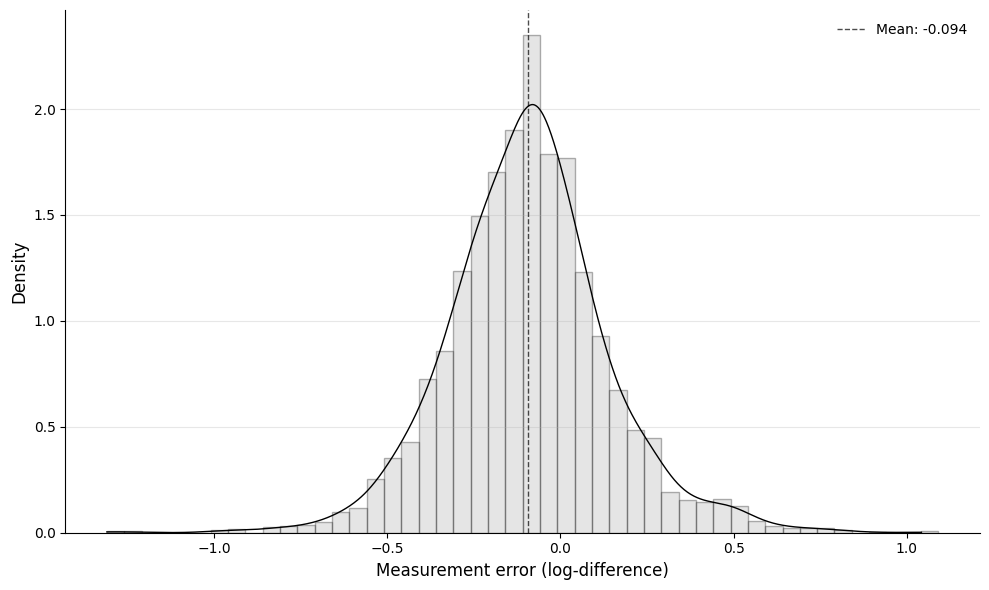

In [22]:
# Plot measurement error distribution in logs
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Calculate weighted mean of measurement error
me_mean = np.average(valid_df['measurement_error_log'], weights=valid_df['soep_n_obs_actual'])

# Define bins of 0.05
bins = np.arange(valid_df['measurement_error_log'].min(), valid_df['measurement_error_log'].max() + 0.05, 0.05)

# Plot histogram
ax.hist(valid_df['measurement_error_log'], bins=bins, weights=valid_df['soep_n_obs_actual'], 
        alpha=0.3, color='darkgrey', edgecolor='black', density=True)

# Add KDE
kde_me = gaussian_kde(valid_df['measurement_error_log'], weights=valid_df['soep_n_obs_actual'])
x_range = np.linspace(valid_df['measurement_error_log'].min(), valid_df['measurement_error_log'].max(), 1000)
ax.plot(x_range, kde_me(x_range), color='black', linewidth=1, linestyle='-')

# Add vertical line for mean
ax.axvline(me_mean, color='black', linewidth=1, linestyle='--', alpha=0.7, label=f'Mean: {me_mean:.3f}')

ax.set_xlabel('Measurement error (log-difference)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

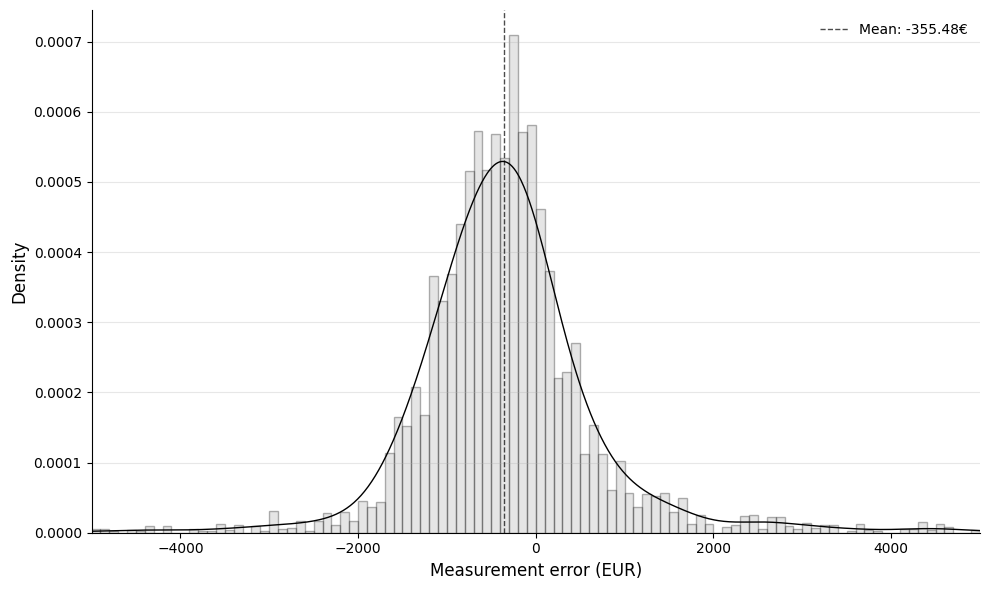

In [23]:
# Plot nominal measurement error distribution
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Calculate weighted mean of measurement error
me_mean = np.average(valid_df['measurement_error'], weights=valid_df['soep_n_obs_actual'])

# Define bins (100 euro bins) and limit range to -5000 to +5000
bin_width = 100
bins = np.arange(-5000, 5000 + bin_width, bin_width)

# Plot histogram
ax.hist(valid_df['measurement_error'], bins=bins, weights=valid_df['soep_n_obs_actual'], 
        alpha=0.3, color='darkgrey', edgecolor='black', density=True)

# Add KDE
kde_me = gaussian_kde(valid_df['measurement_error'], weights=valid_df['soep_n_obs_actual'])
x_range = np.linspace(-5000, 5000, 1000)
ax.plot(x_range, kde_me(x_range), color='black', linewidth=1, linestyle='-')

# Add vertical line for mean
ax.axvline(me_mean, color='black', linewidth=1, linestyle='--', alpha=0.7, label=f'Mean: {me_mean:.2f}€')

ax.set_xlabel('Measurement error (EUR)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_xlim(-5000, 5000)
ax.legend(fontsize=10, frameon=False)
ax.grid(True, alpha=0.3, axis='y')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/5h/mgjr5c410p33q26211w0wr640000gn/T/ipykernel_18875/1089803776.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_stats_euro = valid_df.groupby('income_quantile').agg({
/var/folders/5h/mgjr5c410p33q26211w0wr640000gn/T/ipykernel_18875/1089803776.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantile_stats_log = valid_df.groupby('income_quantile').agg({


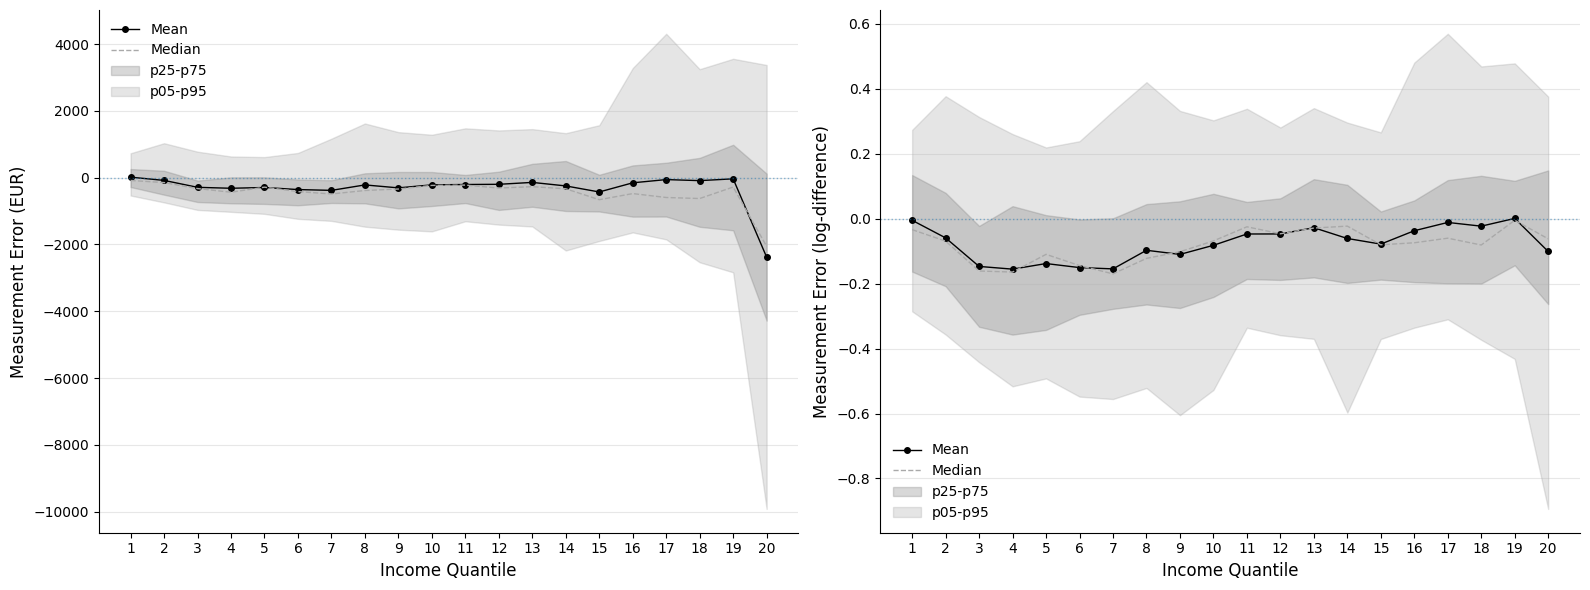

In [24]:
# Measurement error distribution by earning quantiles

# Create 20 quantiles based on SOEP earnings
valid_df['income_quantile'] = pd.qcut(valid_df['pglabgro_mean'], q=20, labels=range(1, 21))

# Calculate statistics for each quantile (in euros)
quantile_stats_euro = valid_df.groupby('income_quantile').agg({
    'measurement_error': ['mean', 'median', 
                          lambda x: x.quantile(0.05),
                          lambda x: x.quantile(0.25), 
                          lambda x: x.quantile(0.75),
                          lambda x: x.quantile(0.95)]
}).reset_index()
quantile_stats_euro.columns = ['quantile', 'mean', 'median', 'p05', 'p25', 'p75', 'p95']

# Calculate statistics for each quantile (in logs)
quantile_stats_log = valid_df.groupby('income_quantile').agg({
    'measurement_error_log': ['mean', 'median',
                              lambda x: x.quantile(0.05),
                              lambda x: x.quantile(0.25),
                              lambda x: x.quantile(0.75),
                              lambda x: x.quantile(0.95)]
}).reset_index()
quantile_stats_log.columns = ['quantile', 'mean', 'median', 'p05', 'p25', 'p75', 'p95']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Measurement error in euros
axes[0].fill_between(quantile_stats_euro['quantile'], quantile_stats_euro['p05'], quantile_stats_euro['p95'],
                      alpha=0.2, color='grey', label='p05-p95')
axes[0].fill_between(quantile_stats_euro['quantile'], quantile_stats_euro['p25'], quantile_stats_euro['p75'],
                      alpha=0.3, color='grey', label='p25-p75')
axes[0].plot(quantile_stats_euro['quantile'], quantile_stats_euro['mean'], 
             color='black', linewidth=1, linestyle='-', marker='o', markersize=4, label='Mean')
axes[0].plot(quantile_stats_euro['quantile'], quantile_stats_euro['median'],
             color='darkgrey', linewidth=1, linestyle='--', markersize=4, label='Median')
axes[0].axhline(0, linewidth=1, linestyle=':', alpha=0.5)
axes[0].set_xlabel('Income Quantile', fontsize=12)
axes[0].set_ylabel('Measurement Error (EUR)', fontsize=12)
axes[0].set_xticks(range(1, 21))
axes[0].set_xticklabels(range(1, 21))
# Reorder legend: mean, median, p25-p75, p05-p95
handles, labels = axes[0].get_legend_handles_labels()
order = [2, 3, 1, 0]  # mean, median, p25-p75, p05-p95
axes[0].legend([handles[i] for i in order], [labels[i] for i in order], fontsize=10, frameon=False)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Measurement error in logs
axes[1].fill_between(quantile_stats_log['quantile'], quantile_stats_log['p05'], quantile_stats_log['p95'],
                      alpha=0.2, color='grey', label='p05-p95')
axes[1].fill_between(quantile_stats_log['quantile'], quantile_stats_log['p25'], quantile_stats_log['p75'],
                      alpha=0.3, color='grey', label='p25-p75')
axes[1].plot(quantile_stats_log['quantile'], quantile_stats_log['mean'],
             color='black', linewidth=1, linestyle='-', marker='o', markersize=4, label='Mean')
axes[1].plot(quantile_stats_log['quantile'], quantile_stats_log['median'],
             color='darkgrey', linewidth=1, linestyle='--', markersize=4, label='Median')
axes[1].axhline(0, linewidth=1, linestyle=':', alpha=0.5)
axes[1].set_xlabel('Income Quantile', fontsize=12)
axes[1].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[1].set_xticks(range(1, 21))
axes[1].set_xticklabels(range(1, 21))
# Reorder legend: mean, median, p25-p75, p05-p95
handles, labels = axes[1].get_legend_handles_labels()
order = [2, 3, 1, 0]  # mean, median, p25-p75, p05-p95
axes[1].legend([handles[i] for i in order], [labels[i] for i in order], fontsize=10, frameon=False)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation with observables and regression analysis

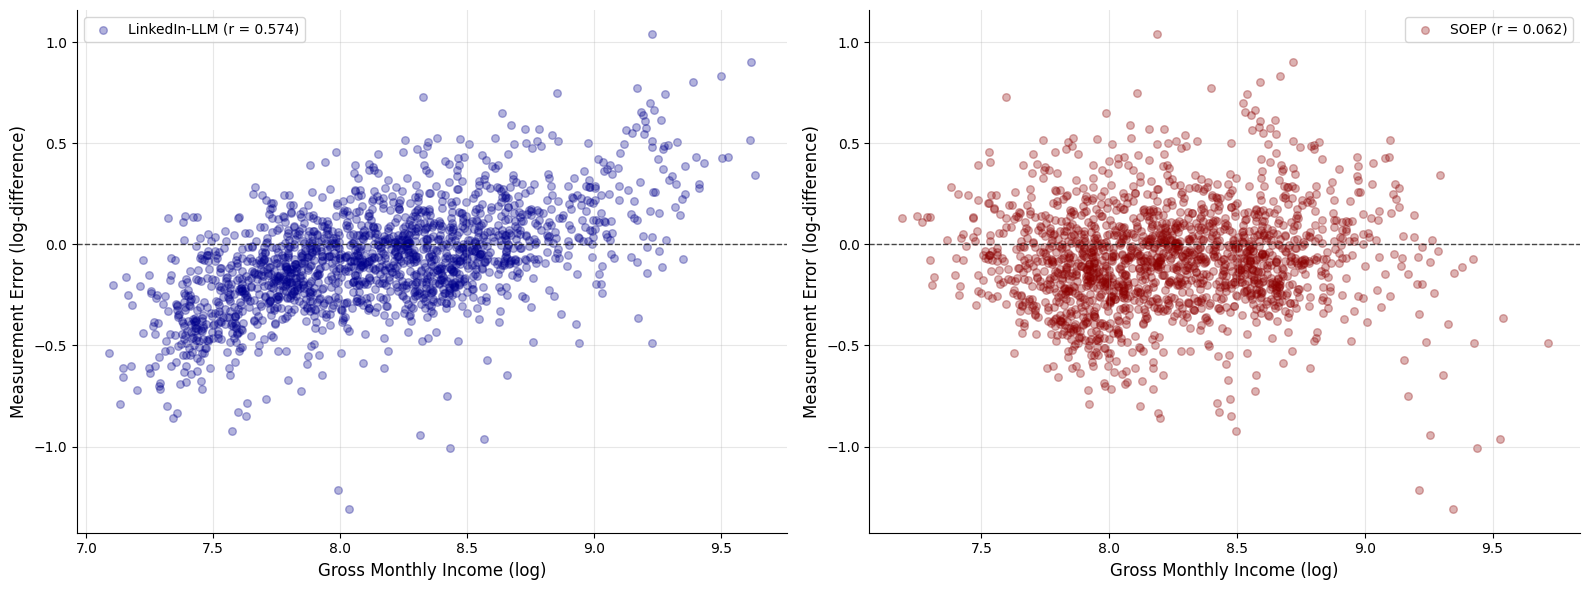

In [25]:
# Scatter plot: Measurement error vs income levels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate correlations
corr_linkedin = valid_df['log_llm_income_mean'].corr(valid_df['measurement_error_log'])
corr_soep = valid_df['log_pglabgro_mean'].corr(valid_df['measurement_error_log'])

# Left panel: Measurement error vs LinkedIn-LLM income
axes[0].scatter(valid_df['log_llm_income_mean'], valid_df['measurement_error_log'], 
                alpha=0.3, color='darkblue', s=30, label=f'LinkedIn-LLM (r = {corr_linkedin:.3f})')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
axes[0].set_xlabel('Gross Monthly Income (log)', fontsize=12)
axes[0].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[0].legend(fontsize=10, frameon=True)
axes[0].grid(True, alpha=0.3)
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

# Right panel: Measurement error vs SOEP income
axes[1].scatter(valid_df['log_pglabgro_mean'], valid_df['measurement_error_log'], 
                alpha=0.3, color='darkred', s=30, label=f'SOEP (r = {corr_soep:.3f})')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
axes[1].set_xlabel('Gross Monthly Income (log)', fontsize=12)
axes[1].set_ylabel('Measurement Error (log-difference)', fontsize=12)
axes[1].legend(fontsize=10, frameon=True)
axes[1].grid(True, alpha=0.3)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

In [26]:
# Regression of measurement error on true SOEP earnings
# This tests whether measurement error is systematically related to earnings level

# Prepare regression data
X_soep = valid_df[['log_pglabgro_mean']].copy()
X_soep = sm.add_constant(X_soep)
y_me = valid_df['measurement_error_log'].values
weights_me = valid_df['soep_n_obs_actual'].values

# Fit weighted OLS with robust standard errors
model_me_on_soep = sm.WLS(y_me, X_soep, weights=weights_me)
results_me_on_soep = model_me_on_soep.fit(cov_type='HC3')

# Print regression results
print("="*80)
print("Weighted OLS: Measurement Error (log) on True SOEP Earnings (log)")
print("="*80)
print(results_me_on_soep.summary())
print("\n")

# Calculate R-squared
print(f"R-squared: {results_me_on_soep.rsquared:.4f}")
print(f"Adjusted R-squared: {results_me_on_soep.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_me = results_me_on_soep.predict(X_soep)
rmse_me = np.sqrt(mean_squared_error(y_me, y_pred_me, sample_weight=weights_me))
mae_me = mean_absolute_error(y_me, y_pred_me, sample_weight=weights_me)

print(f"Weighted RMSE: {rmse_me:.4f}")
print(f"Weighted MAE: {mae_me:.4f}")
print("\n")

# Interpret the coefficient
beta_soep = results_me_on_soep.params['log_pglabgro_mean']
se_soep = results_me_on_soep.bse['log_pglabgro_mean']
pval_soep = results_me_on_soep.pvalues['log_pglabgro_mean']

print(f"Coefficient on log(SOEP earnings): {beta_soep:.4f} (SE: {se_soep:.4f}, p-value: {pval_soep:.4e})")
if pval_soep < 0.001:
    sig_str = "***"
elif pval_soep < 0.01:
    sig_str = "**"
elif pval_soep < 0.05:
    sig_str = "*"
else:
    sig_str = ""
print(f"Significance: {sig_str}")
print("\n")

# Interpretation
if abs(beta_soep) < 0.01:
    print("The measurement error is essentially unrelated to true earnings level.")
elif beta_soep > 0:
    print(f"The measurement error INCREASES by {beta_soep:.4f} log points for each 1 log point")
    print("increase in true SOEP earnings. LinkedIn-LLM estimates tend to OVERESTIMATE")
    print("earnings more for higher earners (or underestimate less).")
else:
    print(f"The measurement error DECREASES by {abs(beta_soep):.4f} log points for each 1 log point")
    print("increase in true SOEP earnings. LinkedIn-LLM estimates tend to UNDERESTIMATE")
    print("earnings more for higher earners (or overestimate less).")
print("="*80)

Weighted OLS: Measurement Error (log) on True SOEP Earnings (log)
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.009
Model:                            WLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     12.36
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000450
Time:                        23:09:18   Log-Likelihood:                -53.967
No. Observations:                1721   AIC:                             111.9
Df Residuals:                    1719   BIC:                             122.8
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [27]:
# Regression of measurement error (in euros) on true SOEP earnings (in euros)
# This tests whether measurement error in nominal terms is systematically related to earnings level

# Prepare regression data
X_soep_euro = valid_df[['pglabgro_mean']].copy()
X_soep_euro = sm.add_constant(X_soep_euro)
y_me_euro = valid_df['measurement_error'].values
weights_me_euro = valid_df['soep_n_obs_actual'].values

# Fit weighted OLS with robust standard errors
model_me_on_soep_euro = sm.WLS(y_me_euro, X_soep_euro, weights=weights_me_euro)
results_me_on_soep_euro = model_me_on_soep_euro.fit(cov_type='HC3')

# Print regression results
print("="*80)
print("Weighted OLS: Measurement Error (EUR) on True SOEP Earnings (EUR)")
print("="*80)
print(results_me_on_soep_euro.summary())
print("\n")

# Calculate R-squared
print(f"R-squared: {results_me_on_soep_euro.rsquared:.4f}")
print(f"Adjusted R-squared: {results_me_on_soep_euro.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_me_euro = results_me_on_soep_euro.predict(X_soep_euro)
rmse_me_euro = np.sqrt(mean_squared_error(y_me_euro, y_pred_me_euro, sample_weight=weights_me_euro))
mae_me_euro = mean_absolute_error(y_me_euro, y_pred_me_euro, sample_weight=weights_me_euro)

print(f"Weighted RMSE: {rmse_me_euro:.2f}€")
print(f"Weighted MAE: {mae_me_euro:.2f}€")
print("\n")

# Interpret the coefficient
beta_soep_euro = results_me_on_soep_euro.params['pglabgro_mean']
se_soep_euro = results_me_on_soep_euro.bse['pglabgro_mean']
pval_soep_euro = results_me_on_soep_euro.pvalues['pglabgro_mean']

print(f"Coefficient on SOEP earnings: {beta_soep_euro:.4f} (SE: {se_soep_euro:.4f}, p-value: {pval_soep_euro:.4e})")
if pval_soep_euro < 0.001:
    sig_str = "***"
elif pval_soep_euro < 0.01:
    sig_str = "**"
elif pval_soep_euro < 0.05:
    sig_str = "*"
else:
    sig_str = ""
print(f"Significance: {sig_str}")
print("\n")

# Interpretation
if abs(beta_soep_euro) < 0.01:
    print("The measurement error is essentially unrelated to true earnings level.")
elif beta_soep_euro > 0:
    print(f"The measurement error INCREASES by {beta_soep_euro:.4f}€ for each 1€")
    print("increase in true SOEP earnings. LinkedIn-LLM estimates tend to OVERESTIMATE")
    print("earnings more for higher earners (or underestimate less).")
else:
    print(f"The measurement error DECREASES by {abs(beta_soep_euro):.4f}€ for each 1€")
    print("increase in true SOEP earnings. LinkedIn-LLM estimates tend to UNDERESTIMATE")
    print("earnings more for higher earners (or overestimate less).")
print("="*80)

Weighted OLS: Measurement Error (EUR) on True SOEP Earnings (EUR)
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.080
Model:                            WLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     21.36
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           4.08e-06
Time:                        23:09:18   Log-Likelihood:                -14856.
No. Observations:                1721   AIC:                         2.972e+04
Df Residuals:                    1719   BIC:                         2.973e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

In [28]:
# Prepare dataframes for regression

covariates = ['sex_en', 'education_grouped', 'state_en', 'isco_3_name', 'syear']

# Add experience variables if available
if 'pgexpft_mean' in valid_df.columns:
    covariates.append('pgexpft_mean')
if 'pgexpft_sq_mean' in valid_df.columns:
    covariates.append('pgexpft_sq_mean')

# Prepare the data for regression - drop any rows with missing values in key variables
regression_df = valid_df[['measurement_error_log', 'log_llm_income_mean', 'log_pglabgro_mean', 'soep_n_obs_actual'] + covariates].dropna().copy()
regression_df['syear'] = regression_df['syear'].astype(str)

print(f"Observations for regression: {len(regression_df)}")
print(f"Weighted observations: {regression_df['soep_n_obs_actual'].sum():.0f}")

Observations for regression: 1721
Weighted observations: 17132


In [29]:
# Regression of measurement error (log) on covariates

# Combine all features
X = pd.get_dummies(regression_df[covariates], drop_first=True, dtype=float)

# Add constant
X = sm.add_constant(X)

# Dependent variable
y = regression_df['measurement_error_log'].values

# Weights
weights = regression_df['soep_n_obs_actual'].values

# Fit weighted OLS with robust standard errors
model = sm.WLS(y, X, weights=weights)
results = model.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("Weighted OLS Regression: Measurement Error (log) on Covariates - LinkedIn Data")
print("="*80)
print(results.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results.params)) if i != 0]
f_test = results.f_test(np.eye(len(results.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test.fvalue:.4f}")
print(f"P-value: {f_test.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred = results.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred, sample_weight=weights))
mae = mean_absolute_error(y, y_pred, sample_weight=weights)

print(f"Weighted RMSE: {rmse:.4f}")
print(f"Weighted MAE: {mae:.4f}")
print("="*80)

Weighted OLS Regression: Measurement Error (log) on Covariates - LinkedIn Data
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.561
Model:                            WLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     23.95
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          1.10e-241
Time:                        23:09:18   Log-Likelihood:                 646.59
No. Observations:                1721   AIC:                            -1103.
Df Residuals:                    1626   BIC:                            -585.4
Df Model:                          94                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z     

In [30]:
# Regression of log_llm_income_mean on covariates
# Using the same feature matrix X from the previous regression

# Dependent variable - log LLM income
y_llm = regression_df['log_llm_income_mean'].values

# Fit weighted OLS with robust standard errors (using same X and weights)
model_llm = sm.WLS(y_llm, X, weights=weights)
results_llm = model_llm.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("Weighted OLS Regression: log(LinkedIn-LLM Income) on Covariates")
print("="*80)
print(results_llm.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results_llm.params)) if i != 0]
f_test_llm = results_llm.f_test(np.eye(len(results_llm.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test_llm.fvalue:.4f}")
print(f"P-value: {f_test_llm.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results_llm.rsquared:.4f}")
print(f"Adjusted R-squared: {results_llm.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_llm = results_llm.predict(X)
rmse_llm = np.sqrt(mean_squared_error(y_llm, y_pred_llm, sample_weight=weights))
mae_llm = mean_absolute_error(y_llm, y_pred_llm, sample_weight=weights)

print(f"Weighted RMSE: {rmse_llm:.4f}")
print(f"Weighted MAE: {mae_llm:.4f}")
print("="*80)

Weighted OLS Regression: log(LinkedIn-LLM Income) on Covariates
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.968
Model:                            WLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     674.5
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:09:19   Log-Likelihood:                 1675.6
No. Observations:                1721   AIC:                            -3161.
Df Residuals:                    1626   BIC:                            -2643.
Df Model:                          94                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z      P>|z|      [0.

In [31]:
# Regression of log_pglabgro_mean (SOEP wages) on covariates
# Using the same feature matrix X from the previous regressions

# Dependent variable - log SOEP income
y_soep = regression_df['log_pglabgro_mean'].values

# Fit weighted OLS with robust standard errors (using same X and weights)
model_soep = sm.WLS(y_soep, X, weights=weights)
results_soep = model_soep.fit(cov_type='HC3')  # HC3 robust standard errors

# Print regression summary
print("="*80)
print("Weighted OLS Regression: log(SOEP Income) on Covariates")
print("="*80)
print(results_soep.summary())
print("\n")

# F-statistic for H0: all coefficients = 0 (except constant)
# Get indices of all coefficients except constant
non_const_indices = [i for i in range(len(results_soep.params)) if i != 0]
f_test_soep = results_soep.f_test(np.eye(len(results_soep.params))[non_const_indices])
print(f"F-statistic for H0: all β = 0: {f_test_soep.fvalue:.4f}")
print(f"P-value: {f_test_soep.pvalue:.4e}")
print("\n")

# Calculate R-squared
print(f"R-squared: {results_soep.rsquared:.4f}")
print(f"Adjusted R-squared: {results_soep.rsquared_adj:.4f}")
print("\n")

# Calculate RMSE and MAE
y_pred_soep = results_soep.predict(X)
rmse_soep = np.sqrt(mean_squared_error(y_soep, y_pred_soep, sample_weight=weights))
mae_soep = mean_absolute_error(y_soep, y_pred_soep, sample_weight=weights)

print(f"Weighted RMSE: {rmse_soep:.4f}")
print(f"Weighted MAE: {mae_soep:.4f}")
print("="*80)

Weighted OLS Regression: log(SOEP Income) on Covariates
                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.895
Model:                            WLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     176.2
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:09:19   Log-Likelihood:                 968.58
No. Observations:                1721   AIC:                            -1747.
Df Residuals:                    1626   BIC:                            -1229.
Df Model:                          94                                         
Covariance Type:                  HC3                                         
                                                                                                    coef    std err          z      P>|z|      [0.025     

In [32]:
# Create comparison table of regression results

# Function to format coefficient with std error and significance
def format_coef(coef, se, pval):
    """Format coefficient with standard error and significance stars"""
    stars = ''
    if pval < 0.001:
        stars = '***'
    elif pval < 0.01:
        stars = '**'
    elif pval < 0.05:
        stars = '*'
    return f"{coef:.4f}{stars}\n({se:.4f})"

# Extract parameters from all three models
params_me = results.params
se_me = results.bse
pval_me = results.pvalues

params_llm = results_llm.params
se_llm = results_llm.bse
pval_llm = results_llm.pvalues

params_soep = results_soep.params
se_soep = results_soep.bse
pval_soep = results_soep.pvalues

# Create list of rows for the table
table_data = []

# Group variables by type
sex_vars = [v for v in params_me.index if v.startswith('sex_')]
education_vars = [v for v in params_me.index if v.startswith('education_')]
occupation_vars = [v for v in params_me.index if v.startswith('isco_3_name_')]
state_vars = [v for v in params_me.index if v.startswith('state_')]
year_vars = [v for v in params_me.index if v.startswith('syear_')]
experience_vars = ['pgexpft_mean', 'pgexpft_sq_mean'] if 'pgexpft_mean' in params_me.index else []

# Add constant
if 'const' in params_me.index:
    table_data.append({
        'Variable': 'Constant',
        'Measurement Error': format_coef(params_me['const'], se_me['const'], pval_me['const']),
        'LinkedIn-LLM Income': format_coef(params_llm['const'], se_llm['const'], pval_llm['const']),
        'SOEP Income': format_coef(params_soep['const'], se_soep['const'], pval_soep['const'])
    })

# Add experience variables
if experience_vars:
    table_data.append({'Variable': '--- Experience ---', 'Measurement Error': '', 'LinkedIn-LLM Income': '', 'SOEP Income': ''})
    for var in experience_vars:
        if var in params_me.index:
            table_data.append({
                'Variable': var,
                'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
                'LinkedIn-LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
                'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
            })

# Add sex variables
if sex_vars:
    table_data.append({'Variable': '--- Sex ---', 'Measurement Error': '', 'LinkedIn-LLM Income': '', 'SOEP Income': ''})
    for var in sex_vars:
        table_data.append({
            'Variable': var.replace('sex_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LinkedIn-LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add education variables
if education_vars:
    table_data.append({'Variable': '--- Education ---', 'Measurement Error': '', 'LinkedIn-LLM Income': '', 'SOEP Income': ''})
    for var in education_vars:
        table_data.append({
            'Variable': var.replace('education_grouped_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LinkedIn-LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add top 5 occupation variables by absolute coefficient value (using measurement error)
if occupation_vars:
    occ_abs_coefs = {var: abs(params_me[var]) for var in occupation_vars}
    top_5_occ = sorted(occ_abs_coefs.items(), key=lambda x: x[1], reverse=True)[:5]
    table_data.append({'Variable': '--- Occupation (Top 5) ---', 'Measurement Error': '', 'LinkedIn-LLM Income': '', 'SOEP Income': ''})
    for var, _ in top_5_occ:
        table_data.append({
            'Variable': var.replace('isco_3_name_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LinkedIn-LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add top 5 state variables by absolute coefficient value (using measurement error)
if state_vars:
    state_abs_coefs = {var: abs(params_me[var]) for var in state_vars}
    top_5_state = sorted(state_abs_coefs.items(), key=lambda x: x[1], reverse=True)[:5]
    table_data.append({'Variable': '--- State (Top 5) ---', 'Measurement Error': '', 'LinkedIn-LLM Income': '', 'SOEP Income': ''})
    for var, _ in top_5_state:
        table_data.append({
            'Variable': var.replace('state_', ''),
            'Measurement Error': format_coef(params_me[var], se_me[var], pval_me[var]),
            'LinkedIn-LLM Income': format_coef(params_llm[var], se_llm[var], pval_llm[var]),
            'SOEP Income': format_coef(params_soep[var], se_soep[var], pval_soep[var])
        })

# Add model statistics
table_data.append({'Variable': '', 'Measurement Error': '', 'LinkedIn-LLM Income': '', 'SOEP Income': ''})
table_data.append({'Variable': '--- Model Statistics ---', 'Measurement Error': '', 'LinkedIn-LLM Income': '', 'SOEP Income': ''})

# Time fixed effects
time_fe = 'Yes' if year_vars else 'No'
table_data.append({
    'Variable': 'Time Fixed Effects',
    'Measurement Error': time_fe,
    'LinkedIn-LLM Income': time_fe,
    'SOEP Income': time_fe
})

# F-statistic
table_data.append({
    'Variable': 'F-statistic',
    'Measurement Error': f"{f_test.fvalue:.2f}",
    'LinkedIn-LLM Income': f"{f_test_llm.fvalue:.2f}",
    'SOEP Income': f"{f_test_soep.fvalue:.2f}"
})

# R-squared
table_data.append({
    'Variable': 'R-squared',
    'Measurement Error': f"{results.rsquared:.4f}",
    'LinkedIn-LLM Income': f"{results_llm.rsquared:.4f}",
    'SOEP Income': f"{results_soep.rsquared:.4f}"
})

# Number of observations
table_data.append({
    'Variable': 'Observations',
    'Measurement Error': f"{int(results.nobs)}",
    'LinkedIn-LLM Income': f"{int(results_llm.nobs)}",
    'SOEP Income': f"{int(results_soep.nobs)}"
})

# Create DataFrame and display
comparison_table = pd.DataFrame(table_data)
print("="*100)
print("REGRESSION RESULTS COMPARISON - LinkedIn Data")
print("="*100)
print("\nNote: Standard errors in parentheses. *** p<0.001, ** p<0.01, * p<0.05")
print("\n")
print(comparison_table.to_string(index=False))
print("\n" + "="*100)

REGRESSION RESULTS COMPARISON - LinkedIn Data

Note: Standard errors in parentheses. *** p<0.001, ** p<0.01, * p<0.05


                                                     Variable    Measurement Error  LinkedIn-LLM Income          SOEP Income
                                                     Constant -0.2735***\n(0.0538)  8.0110***\n(0.0235)  8.2845***\n(0.0481)
                                           --- Experience ---                                                               
                                                 pgexpft_mean  0.0311***\n(0.0046)  0.0396***\n(0.0025)    0.0086*\n(0.0035)
                                              pgexpft_sq_mean -0.0806***\n(0.0143) -0.0798***\n(0.0075)     0.0009\n(0.0113)
                                                  --- Sex ---                                                               
                                                      en_male -0.1129***\n(0.0140)  0.0928***\n(0.0075)  0.2057***\n(0.0123)
     

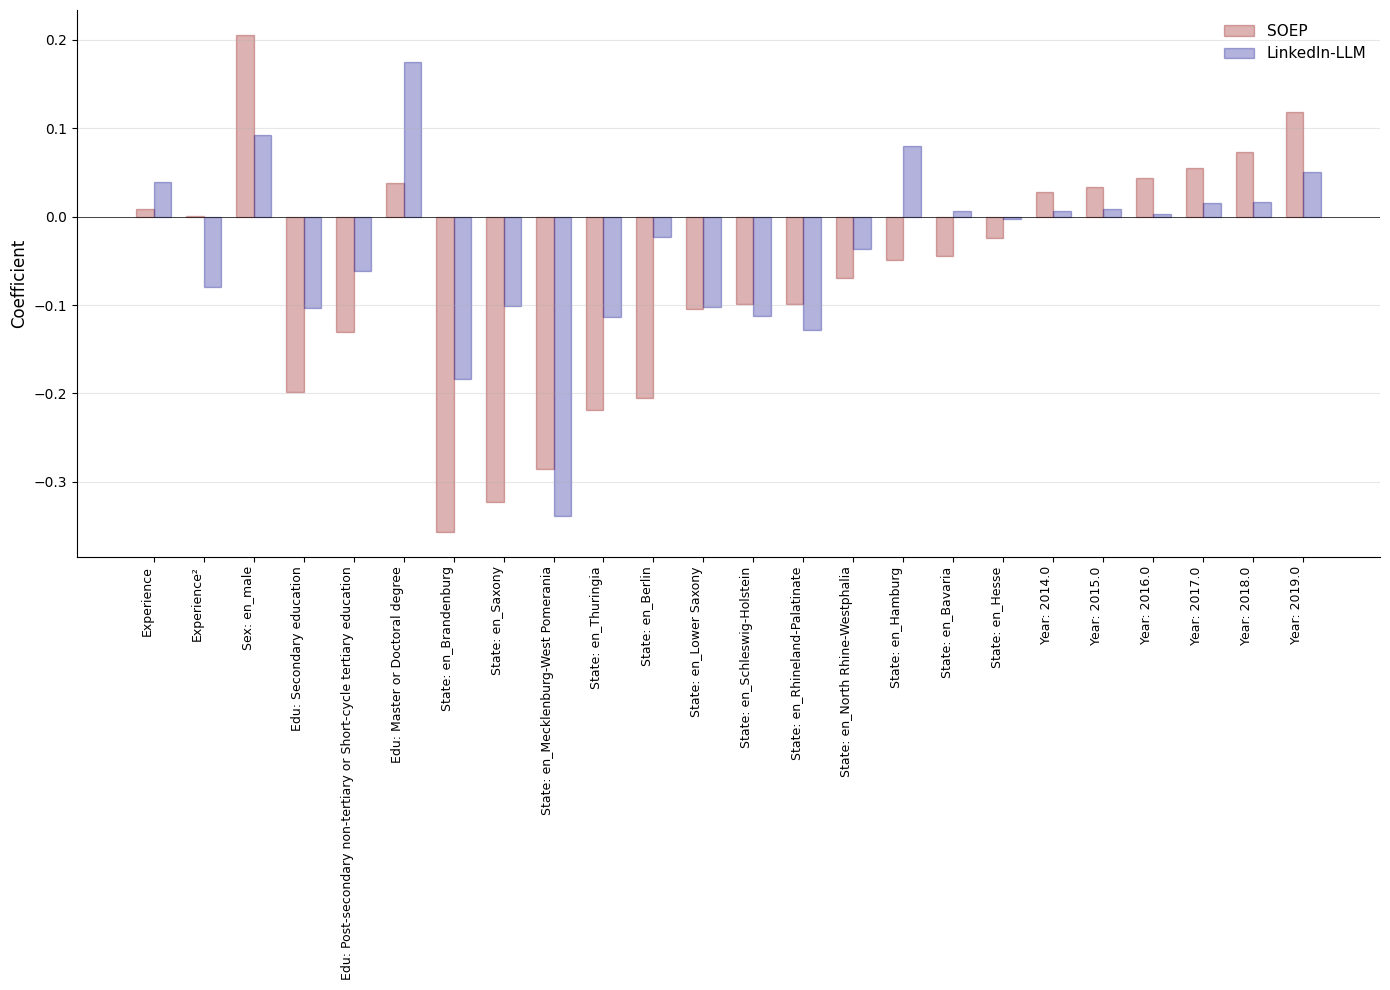

In [33]:
# Visualize coefficient comparison between LinkedIn-LLM and SOEP

# Extract coefficients for variables of interest
experience_vars = ['pgexpft_mean', 'pgexpft_sq_mean'] if 'pgexpft_mean' in params_llm.index else []
sex_vars = [v for v in params_llm.index if v.startswith('sex_')]
education_vars = [v for v in params_llm.index if v.startswith('education_')]
state_vars = [v for v in params_llm.index if v.startswith('state_')]
year_vars = [v for v in params_llm.index if v.startswith('syear_')]

# Sort each category by absolute SOEP coefficient value
sex_vars_sorted = sorted(sex_vars, key=lambda x: abs(params_soep[x]), reverse=True)
education_vars_sorted = sorted(education_vars, key=lambda x: abs(params_soep[x]), reverse=True)
state_vars_sorted = sorted(state_vars, key=lambda x: abs(params_soep[x]), reverse=True)

# Combine all variables (experience stays in original order)
plot_vars = experience_vars + sex_vars_sorted + education_vars_sorted + state_vars_sorted + year_vars

# Create labels (clean variable names)
labels = []
llm_coefs = []
soep_coefs = []

for var in plot_vars:
    if var in params_llm.index and var in params_soep.index:
        # Clean up variable name for display
        if var.startswith('sex_'):
            label = var.replace('sex_', 'Sex: ')
        elif var.startswith('education_'):
            label = var.replace('education_grouped_', 'Edu: ')
        elif var.startswith('state_'):
            label = var.replace('state_', 'State: ')
        elif var == 'pgexpft_mean':
            label = 'Experience'
        elif var == 'pgexpft_sq_mean':
            label = 'Experience²'
        elif var.startswith('syear_'):
            label = var.replace('syear_', 'Year: ')
        else:
            label = var
        
        labels.append(label)
        llm_coefs.append(params_llm[var])
        soep_coefs.append(params_soep[var])

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Set up bar positions
x = np.arange(len(labels))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, soep_coefs, width, label='SOEP', color='darkred', edgecolor='darkred', alpha=0.3)
bars2 = ax.bar(x + width/2, llm_coefs, width, label='LinkedIn-LLM', color='darkblue', edgecolor='darkblue', alpha=0.3)

# Customize plot
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=9)
ax.legend(fontsize=11, frameon=False)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

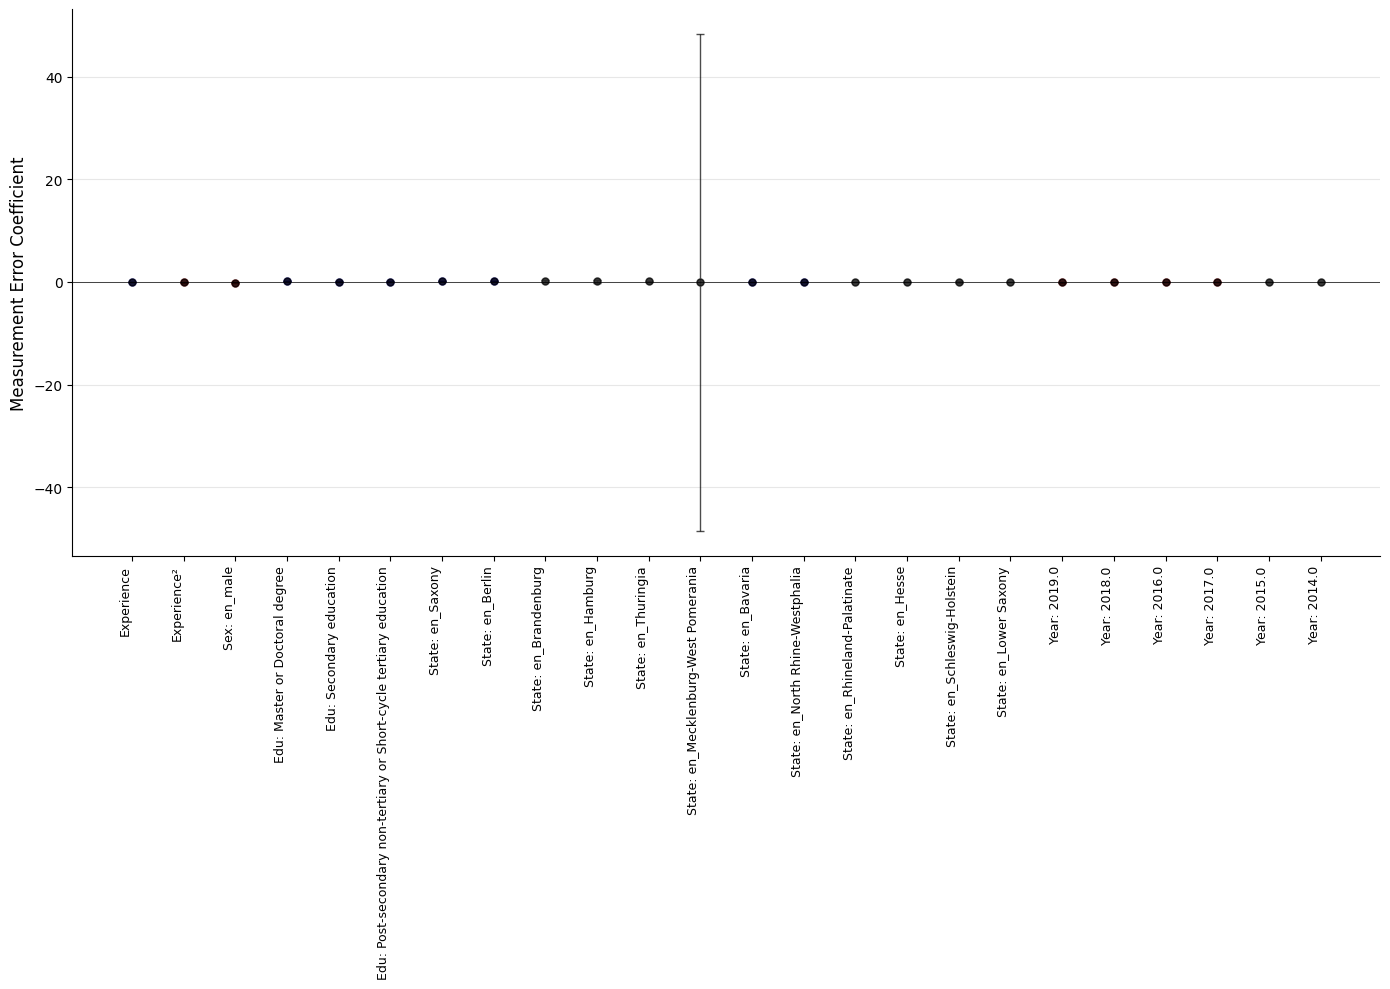

In [34]:
# Visualize measurement error coefficients with confidence intervals

# Extract coefficients for variables of interest
experience_vars = ['pgexpft_mean', 'pgexpft_sq_mean'] if 'pgexpft_mean' in params_me.index else []
sex_vars = [v for v in params_llm.index if v.startswith('sex_')]
education_vars = [v for v in params_llm.index if v.startswith('education_')]
state_vars = [v for v in params_llm.index if v.startswith('state_')]
year_vars = [v for v in params_llm.index if v.startswith('syear_')]

# Sort each category by absolute measurement error coefficient value
sex_vars_sorted = sorted(sex_vars, key=lambda x: abs(params_me[x]), reverse=True)
education_vars_sorted = sorted(education_vars, key=lambda x: abs(params_me[x]), reverse=True)
state_vars_sorted = sorted(state_vars, key=lambda x: abs(params_me[x]), reverse=True)
year_vars_sorted = sorted(year_vars, key=lambda x: abs(params_me[x]), reverse=True)

# Combine all variables (experience stays in original order)
plot_vars = experience_vars + sex_vars_sorted + education_vars_sorted + state_vars_sorted + year_vars_sorted

# Create labels and extract coefficients with standard errors
labels = []
me_coefs = []
me_se = []

for var in plot_vars:
    if var in params_me.index:
        # Clean up variable name for display
        if var.startswith('sex_'):
            label = var.replace('sex_', 'Sex: ')
        elif var.startswith('education_'):
            label = var.replace('education_grouped_', 'Edu: ')
        elif var.startswith('state_'):
            label = var.replace('state_', 'State: ')
        elif var == 'pgexpft_mean':
            label = 'Experience'
        elif var == 'pgexpft_sq_mean':
            label = 'Experience²'
        elif var.startswith('syear_'):
            label = var.replace('syear_', 'Year: ')
        else:
            label = var
        
        labels.append(label)
        me_coefs.append(params_me[var])
        me_se.append(se_me[var])

# Convert to arrays
me_coefs = np.array(me_coefs)
me_se = np.array(me_se)

# Calculate 95% confidence intervals (1.96 * SE)
ci_95 = 1.96 * me_se

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Set up positions
x = np.arange(len(labels))

# Plot coefficients with error bars
# Color points based on whether CI includes zero
colors = ['darkgrey' if (coef - ci < 0 and coef + ci > 0) else ('darkred' if coef < 0 else 'darkblue') 
          for coef, ci in zip(me_coefs, ci_95)]

ax.errorbar(x, me_coefs, yerr=ci_95, fmt='o', color='black', ecolor='black', 
            capsize=3, capthick=1, markersize=5, linewidth=1, alpha=0.7)

# Color the points
for i, (xi, yi, color) in enumerate(zip(x, me_coefs, colors)):
    ax.plot(xi, yi, 'o', color=color, markersize=5, alpha=0.7)

# Customize plot
ax.set_ylabel('Measurement Error Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=9)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

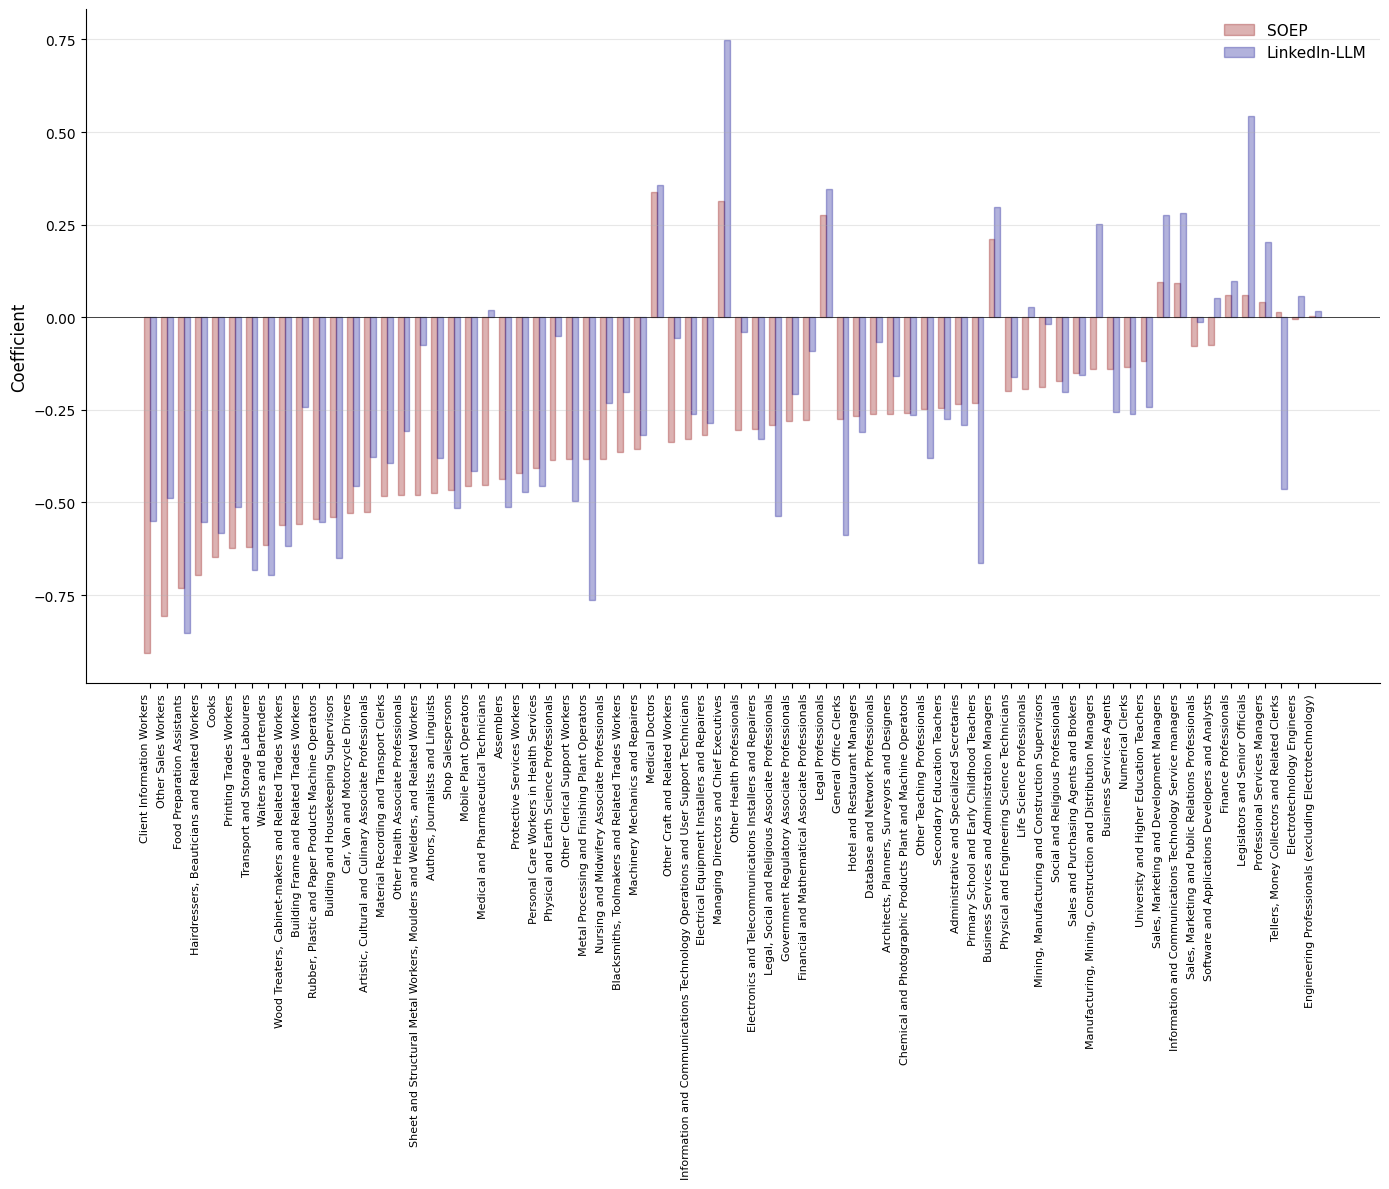

In [35]:
# Visualize coefficient comparison between LinkedIn-LLM and SOEP for occupations

# Extract occupation variables
occupation_vars = [v for v in params_llm.index if v.startswith('isco_3_name_')]

# Sort by absolute SOEP coefficient value
occupation_vars_sorted = sorted(occupation_vars, key=lambda x: abs(params_soep[x]), reverse=True)

# Create labels and extract coefficients
labels = []
llm_coefs = []
soep_coefs = []

for var in occupation_vars_sorted:
    if var in params_llm.index and var in params_soep.index:
        # Clean up variable name for display
        label = var.replace('isco_3_name_', '')
        
        labels.append(label)
        llm_coefs.append(params_llm[var])
        soep_coefs.append(params_soep[var])

# Create figure
fig, ax = plt.subplots(figsize=(14, 12))

# Set up bar positions
x = np.arange(len(labels))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, soep_coefs, width, label='SOEP', color='darkred', edgecolor='darkred', alpha=0.3)
bars2 = ax.bar(x + width/2, llm_coefs, width, label='LinkedIn-LLM', color='darkblue', edgecolor='darkblue', alpha=0.3)

# Customize plot
ax.set_ylabel('Coefficient', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=8)
ax.legend(fontsize=11, frameon=False)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

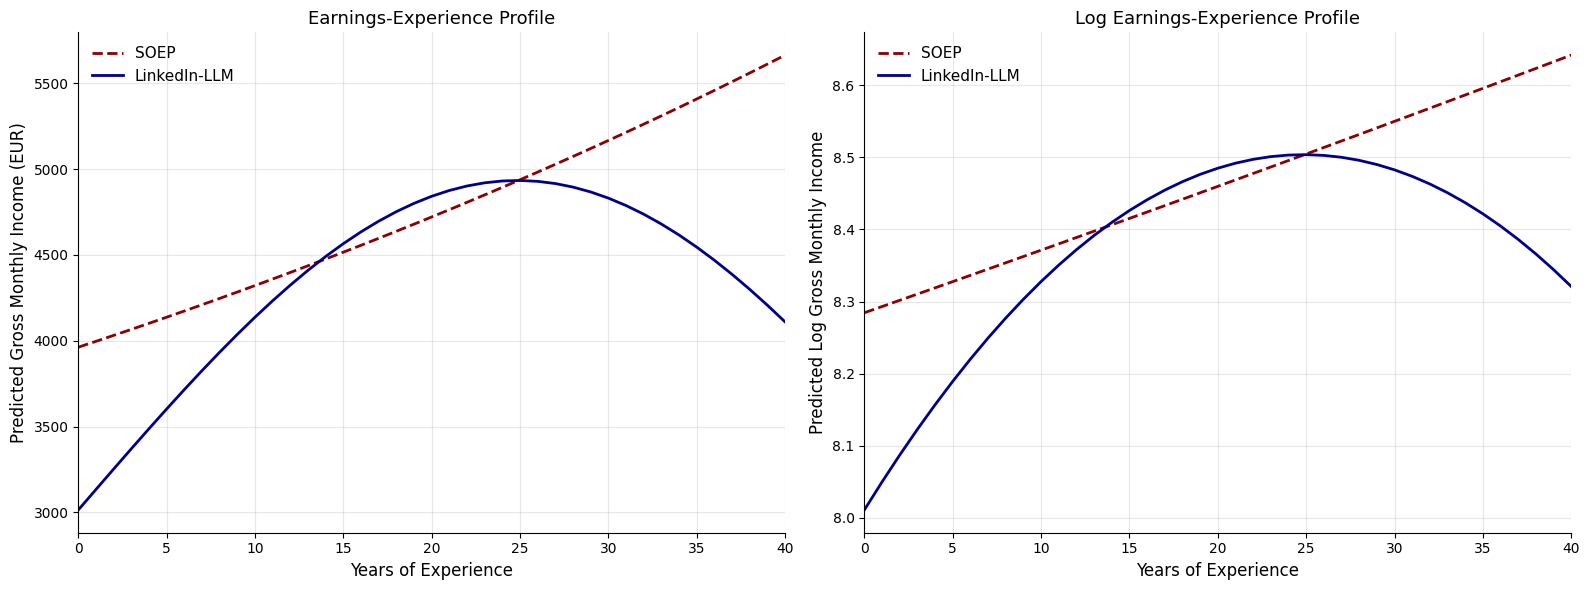

Predicted Earnings at Key Experience Levels

Experience   SOEP (EUR)      LinkedIn-LLM (EUR) Difference (EUR) Difference (%)
--------------------------------------------------------------------------------
0              3,961.95       3,013.83           -948.12       -23.93%
5              4,136.76       3,602.11           -534.65       -12.92%
10             4,321.13       4,136.93           -184.21        -4.26%
15             4,515.64       4,565.41             49.77         1.10%
20             4,720.92       4,841.32            120.40         2.55%
25             4,937.63       4,933.20             -4.43        -0.09%
30             5,166.49       4,830.32           -336.17        -6.51%
35             5,408.26       4,544.70           -863.56       -15.97%
40             5,663.75       4,108.80         -1,554.95       -27.45%


In [36]:
# Visualize predicted earnings by experience - Mincer curves

# Create a range of experience values (0 to 40 years)
exp_range = np.arange(0, 41, 1)

# Create a prediction dataset with varying experience
# We'll hold all other variables at their reference categories or means

# Get the feature matrix column names (excluding const)
feature_cols = [col for col in X.columns if col != 'const']

# Create base prediction dataframe with reference categories (all zeros for dummy variables)
pred_data = pd.DataFrame(0, index=exp_range, columns=feature_cols)

# Set experience variables
if 'pgexpft_mean' in pred_data.columns:
    pred_data['pgexpft_mean'] = exp_range
if 'pgexpft_sq_mean' in pred_data.columns:
    pred_data['pgexpft_sq_mean'] = (exp_range ** 2) / 100

# Add constant
pred_data_with_const = sm.add_constant(pred_data)

# Ensure columns match the order from the regression
pred_data_with_const = pred_data_with_const[X.columns]

# Generate predictions
pred_log_llm = results_llm.predict(pred_data_with_const)
pred_log_soep = results_soep.predict(pred_data_with_const)

# Convert from log to levels (EUR)
pred_llm_levels = np.exp(pred_log_llm)
pred_soep_levels = np.exp(pred_log_soep)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left panel: Predicted earnings in levels (EUR)
axes[0].plot(exp_range, pred_soep_levels, color='darkred', linewidth=2, linestyle='--', label='SOEP')
axes[0].plot(exp_range, pred_llm_levels, color='darkblue', linewidth=2, linestyle='-', label='LinkedIn-LLM')
axes[0].set_xlabel('Years of Experience', fontsize=12)
axes[0].set_ylabel('Predicted Gross Monthly Income (EUR)', fontsize=12)
axes[0].set_title('Earnings-Experience Profile', fontsize=13)
axes[0].legend(fontsize=11, frameon=False)
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xlim(0, 40)

# Right panel: Predicted earnings in logs
axes[1].plot(exp_range, pred_log_soep, color='darkred', linewidth=2, linestyle='--', label='SOEP')
axes[1].plot(exp_range, pred_log_llm, color='darkblue', linewidth=2, linestyle='-', label='LinkedIn-LLM')
axes[1].set_xlabel('Years of Experience', fontsize=12)
axes[1].set_ylabel('Predicted Log Gross Monthly Income', fontsize=12)
axes[1].set_title('Log Earnings-Experience Profile', fontsize=13)
axes[1].legend(fontsize=11, frameon=False)
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_xlim(0, 40)

plt.tight_layout()
plt.show()

# Print some key statistics
print("="*80)
print("Predicted Earnings at Key Experience Levels")
print("="*80)
print(f"\n{'Experience':<12} {'SOEP (EUR)':<15} {'LinkedIn-LLM (EUR)':<18} {'Difference (EUR)':<16} {'Difference (%)'}")
print("-"*80)
for exp in [0, 5, 10, 15, 20, 25, 30, 35, 40]:
    soep_val = pred_soep_levels[exp]
    llm_val = pred_llm_levels[exp]
    diff = llm_val - soep_val
    diff_pct = (diff / soep_val) * 100
    print(f"{exp:<12} {soep_val:>10,.2f}     {llm_val:>10,.2f}        {diff:>10,.2f}      {diff_pct:>7.2f}%")
print("="*80)

In [37]:
valid_df

,syear,isco_3_name,education_grouped,sex_en,state_en,llm_income_mean,log_llm_income_mean,n_obs,pgexpft_mean,pgexpft_sq_mean,pglabgro_mean,log_pglabgro_mean,soep_n_obs_actual,pgexpft_soep_mean,pgexpft_sq_soep_mean,measurement_error,measurement_error_log,income_quantile
0,2013.0,Administration Professionals,Bachelor degree,male,Bavaria,5264.705882,8.497562,17,13.457988,2.671474,4532.000000,8.289442,5,14.383600,3.623667,732.705882,0.208121,13
1,2013.0,Administration Professionals,Master or Doctoral degree,male,North Rhine-Westphalia,6011.904762,8.671379,21,18.507223,4.726055,7342.857143,8.761219,7,18.654714,4.802451,-1330.952381,-0.089840,19
2,2013.0,Administrative and Specialized Secretaries,Post-secondary non-tertiary or Short-cycle ter...,female,North Rhine-Westphalia,2825.757576,7.927402,11,16.142376,3.193664,2480.000000,7.812660,5,18.216800,3.882201,345.757576,0.114742,3
3,2013.0,Administrative and Specialized Secretaries,Secondary education,female,Baden-Württemberg,2486.111111,7.787380,12,6.284102,0.719721,3188.571429,8.016713,7,11.083429,1.733652,-702.460317,-0.229333,7
4,2013.0,Administrative and Specialized Secretaries,Secondary education,female,Bavaria,2717.948718,7.889518,13,9.601065,1.269814,2858.333333,7.870912,6,12.430500,2.113759,-140.384615,0.018606,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716,2019.0,Transport and Storage Labourers,Secondary education,male,North Rhine-Westphalia,1819.444444,7.477090,24,4.352869,0.423715,2130.357143,7.641189,14,12.023786,2.225859,-310.912698,-0.164099,1
1717,2019.0,University and Higher Education Teachers,Master or Doctoral degree,male,Bavaria,4396.825397,8.319980,21,15.374276,3.158940,5714.500000,8.613093,8,16.687500,3.677344,-1317.674603,-0.293112,16
1718,2019.0,University and Higher Education Teachers,Master or Doctoral degree,male,Berlin,3654.761905,8.179843,7,10.925065,1.779173,4698.333333,8.446264,6,5.861167,0.880905,-1043.571429,-0.266420,14
1719,2019.0,University and Higher Education Teachers,Master or Doctoral degree,male,Hesse,4658.730159,8.418519,21,15.862184,3.382294,6354.000000,8.732652,7,15.714286,3.294286,-1695.269841,-0.314133,18
